In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     # pyplot 붙여줘야함
import seaborn as sns

# 한글 깨짐 방지용 Font 지정 | 맑음 고딕 가져오기 | 처음 한번만 지정해 주면 됨
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("C:/Users/human/ku-python/data/orders.csv", encoding='cp949')

# df.describe(include="all")
df["ORDER_DATE"] = pd.to_datetime(df["ORDER_DATE"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ORDER_ID    118 non-null    int64         
 1   ORDER_DATE  118 non-null    datetime64[ns]
 2   AGE         118 non-null    object        
 3   CATEGORY    118 non-null    object        
 4   ITEM_NAME   118 non-null    object        
 5   PRICE       118 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 5.7+ KB


In [3]:
df["AGE_INT"] = df["AGE"].str.replace("대", "")
df["AGE_INT"].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ORDER_ID    118 non-null    int64         
 1   ORDER_DATE  118 non-null    datetime64[ns]
 2   AGE         118 non-null    object        
 3   CATEGORY    118 non-null    object        
 4   ITEM_NAME   118 non-null    object        
 5   PRICE       118 non-null    int64         
 6   AGE_INT     118 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 6.6+ KB


ORDER_DATE
2024=01    31325000
2024=02     2775000
2024=03     2775000
Name: PRICE, dtype: int64
<class 'pandas.core.series.Series'>
Index: 3 entries, 2024-01 to 2024-03
Series name: PRICE
Non-Null Count  Dtype
--------------  -----
3 non-null      int64
dtypes: int64(1)
memory usage: 48.0+ bytes


C:\Users\human\AppData\Local\Temp\ipykernel_5156\1085746614.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test.index, y=test.values, palette="pastel")
C:\Users\human\AppData\Local\Temp\ipykernel_5156\1085746614.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


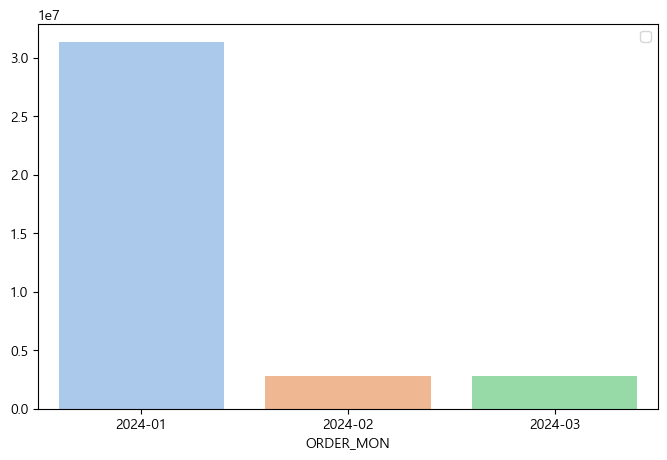

In [77]:
# 월별 총 매출액

# 주문일을 String으로 바꾼 후 인덱싱으로 잘라 월별로 구분
df["ORDER_MON"] = df["ORDER_DATE"].astype(str).str.slice(0, 7)
montly_sale = df.groupby(df["ORDER_DATE"].dt.strftime("%Y=%m"))["PRICE"].sum()
print(montly_sale)

# print(distinct_mon)
test = df.groupby("ORDER_MON")["PRICE"].sum()
test.info()

plt.figure(figsize=(8, 5))
# sns.barplot(x=montly_sale.index, y=montly_sale.values, palette="pastel")
sns.barplot(x=test.index, y=test.values, palette="pastel")
plt.legend()

plt.show()


C:\Users\human\AppData\Local\Temp\ipykernel_5156\1323215861.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["CATEGORY"], data=df, palette="pastel")


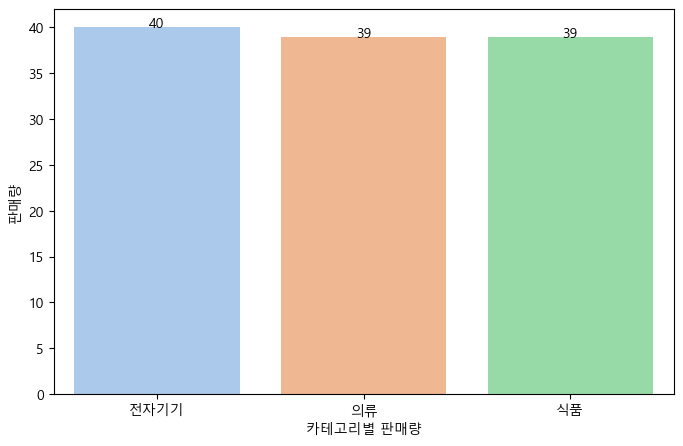

In [104]:
# 카테고리별 판매량 비교

# groupby로 뽑아오는 방식
# DataFrame의 형태로 추출됨으로 ["PRICE"]를 통해 한 열만 가져옴
category_sales = df.groupby("CATEGORY")["PRICE"].count()

# plt.figure(figsize=(8, 5))
# sns.barplot(x=category_sales.index, y=category_sales.values, palette="pastel")
# plt.legend()

# plt.show()

# sns의 countplot 사용
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df["CATEGORY"], data=df, palette="pastel")
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2 ,
            p.get_y() + p.get_height(),
            f"{int(p.get_height())}",
            ha = 'center')

plt.xlabel("카테고리별 판매량")
plt.ylabel("판매량")

plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_5156\1757279290.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="pastel")
C:\Users\human\AppData\Local\Temp\ipykernel_5156\1757279290.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


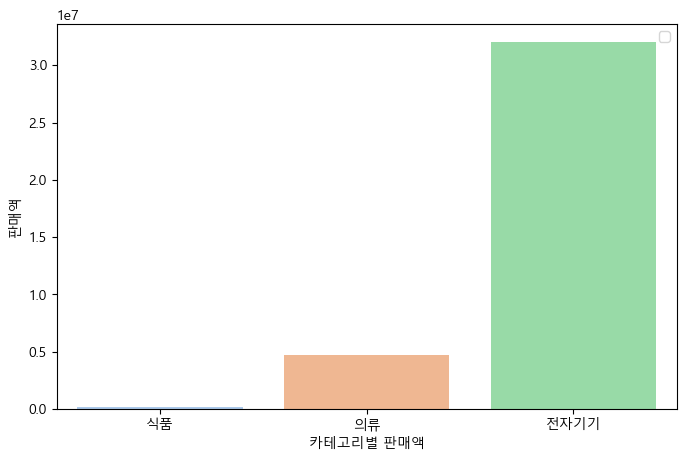

In [105]:
# 카테고리별 판매액 비교

# groupby로 뽑아오는 방식
# DataFrame의 형태로 추출됨으로 ["PRICE"]를 통해 한 열만 가져옴
category_sales = df.groupby("CATEGORY")["PRICE"].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="pastel")
plt.legend()

plt.xlabel("카테고리별 판매액")
plt.ylabel("판매액")

plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_5156\1315065663.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette='Set1')


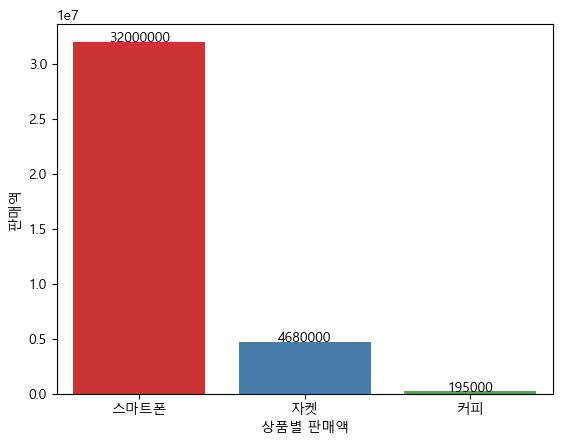

C:\Users\human\AppData\Local\Temp\ipykernel_5156\1315065663.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="ITEM_NAME", y="PRICE", data=df, palette='Set1')


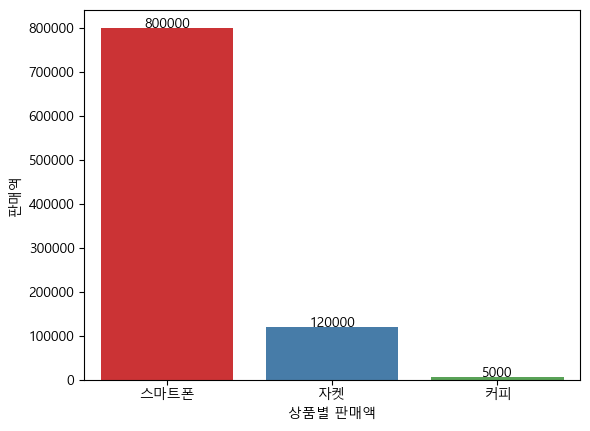

In [112]:
# 인기 상품 분석(판매 금액이 높은 상품)
    # ascending=False : 오름차순 설정 / False면 내림차순
data = df.groupby("ITEM_NAME")["PRICE"].sum().sort_values(ascending=False)

plt.Figure(figsize=(8, 5))
ax = sns.barplot(x=data.index, y=data.values, palette='Set1')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,
            p.get_y() + p.get_height(),
            f"{int(p.get_height())}",
            ha='center')

plt.xlabel("상품별 판매액")
plt.ylabel("판매액")

plt.show()
# 인기 상품 분석(판매 금액이 높은 상품)

plt.Figure(figsize=(8, 5))
ax = sns.barplot(x="ITEM_NAME", y="PRICE", data=df, palette='Set1')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,
            p.get_y() + p.get_height(),
            f"{int(p.get_height())}",
            ha='center')

plt.xlabel("상품별 판매액")
plt.ylabel("판매액")

plt.show()

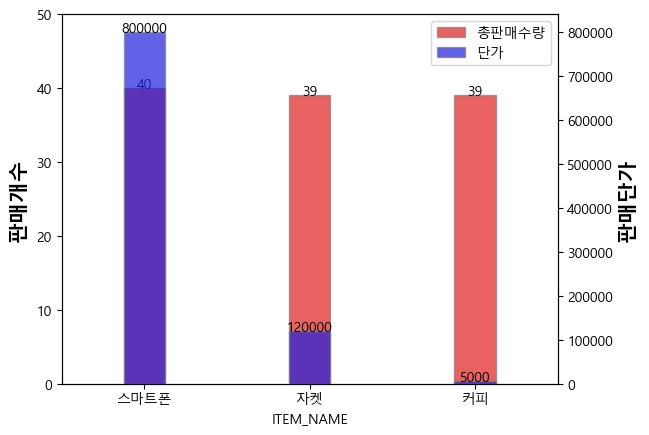

In [ ]:
# 단가와 판매량을 통한 추가분석
test = df.groupby("ITEM_NAME")["PRICE"].count()
test2 = df.groupby("ITEM_NAME")["PRICE"].mean()


plt.Figure(figsize=(8, 5))
barwidth = 0.25

# ax = sns.barplot(x="ITEM_NAME", y="PRICE", data=df, color="red", alpha=0.7, palette='Set1')
ax = sns.barplot(x=test.index, y=test.values, color='red', alpha=0.7, width=barwidth, edgecolor='gray', label='총판매수량', legend=False)
ax2 = ax.twinx()
ax.set_ylim([0, 50])
ax2 = sns.barplot(x=test2.index, y=test2.values, color='blue', alpha=0.7, width=barwidth, edgecolor='gray', label='단가', legend=False)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,
            p.get_y() + p.get_height(),
            f"{int(p.get_height())}",
            ha='center')

for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width() / 2,
            p.get_y() + p.get_height(),
            f"{int(p.get_height())}",
            ha='center')

plt.xlabel("제품명", fontweight='bold', fontsize=15)
ax.set_ylabel("판매개수", fontweight='bold', fontsize=15)
ax2.set_ylabel("판매단가", fontweight='bold', fontsize=15)

# ax.legend(loc='upper right')
# ax2.legend(loc='upper left')

line1, label1 = ax.get_legend_handles_labels()
line2, label2 = ax2.get_legend_handles_labels()

ax.legend(line1 + line2, label1 + label2, loc='upper right')

plt.show()

[0 1 2]
[np.float64(0.2), np.float64(1.2), np.float64(2.2)]


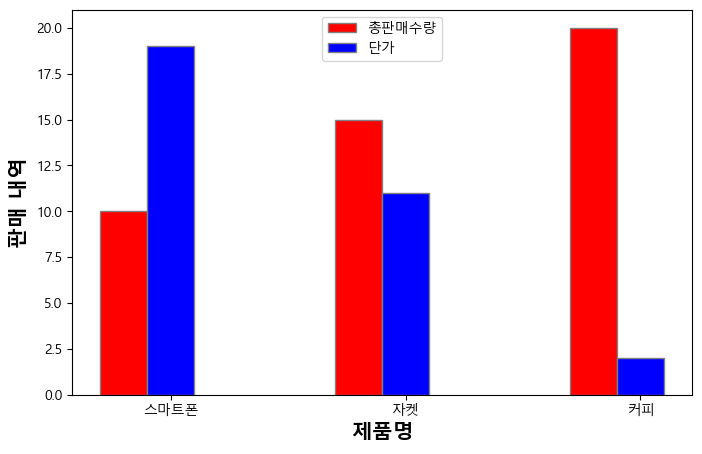

In [8]:
#3. 인기 상품(상품명) 분석(판매 금액이 높은 상품)
top_items = df.groupby("ITEM_NAME")["PRICE"].sum().sort_values(ascending=False)
#plt.figure(figsize=(8, 5))
#sns.barplot(x=top_items.index, y=top_items.values, palette="coolwarm")
#plt.xlabel("상품명")
#plt.ylabel("총 매출액")
#plt.title("인기상품 분석(총판매금액)")
#plt.show()

#top_items_sales_count = df.groupby("ITEM_NAME")["PRICE"].count()
#top_items_unit_price = df.groupby("ITEM_NAME")["PRICE"].mean()

top_items_sales_count = [10, 15, 20]
top_items_unit_price = [19, 11, 2]

barwidth = 0.2
br1 = np.arange(len(top_items_sales_count)) 
br2 = [x + barwidth for x in br1] 

print(br1)
print(br2)

plt.figure(figsize=(8, 5))

plt.bar(br1, top_items_sales_count, color='r', width = barwidth, edgecolor='grey', label='총판매수량')
plt.bar(br2, top_items_unit_price, color='b', width = barwidth, edgecolor='grey', label='단가')

plt.xlabel("제품명", fontweight="bold", fontsize=15)
plt.ylabel("판매 내역", fontweight="bold", fontsize=15)

plt.xticks([r + barwidth for r in range(len(top_items_sales_count))], ['스마트폰', '자켓', '커피'])

plt.legend()
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_4240\3312151248.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group.index, y=age_group.values, palette='pastel')


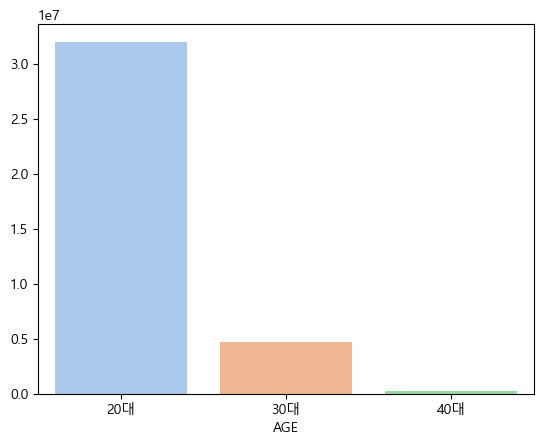

In [ ]:
# 고객 연령대별 구매 패턴 분석

age_group = df.groupby("AGE")["PRICE"].sum()

plt.Figure(figsize=(10, 5))
sns.barplot(x=age_group.index, y=age_group.values, palette='pastel')

plt.show()

In [ ]:
# 시간대별 주문 빈도 분석

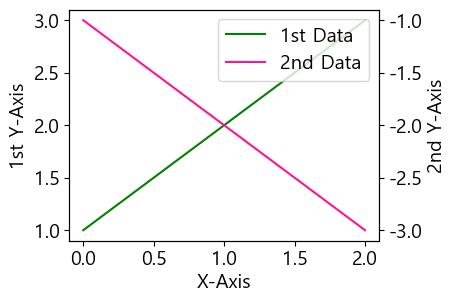

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# plt.style.use('default')
# plt.rcParams['figure.figsize'] = (4, 3)
# plt.rcParams['font.size'] = 14

x = np.arange(0, 3)
y1 = x + 1
y2 = -x - 1

fig, ax1 = plt.subplots()
ax1.set_xlabel('X-Axis')
ax1.set_ylabel('1st Y-Axis')
line1 = ax1.plot(x, y1, color='green', label='1st Data')

ax2 = ax1.twinx()
ax2.set_ylabel('2nd Y-Axis')
line2 = ax2.plot(x, y2, color='deeppink', label='2nd Data')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.show()